### Función para escalonar filas
(programita para triangular matrices)

In [1]:
import numpy as np

def escalonar_filas(M):
    """ 
        Retorna la Matriz Escalonada por Filas 
    """
    A = np.copy(M)
    if (issubclass(A.dtype.type, np.integer)):
        A = A.astype(float)

    # Si A no tiene filas o columnas, ya esta escalonada
    f, c = A.shape
    if f == 0 or c == 0:
        return A

    # buscamos primer elemento no nulo de la primera columna
    i = 0
    
    while i < f and A[i,0] == 0:
        i += 1

    if i == f:
        # si todos los elementos de la primera columna son ceros
        # escalonamos filas desde la segunda columna
        B = escalonar_filas(A[:,1:])
        
        # y volvemos a agregar la primera columna de zeros
        return np.block([A[:,:1], B])


    # intercambiamos filas i <-> 0, pues el primer cero aparece en la fila i
    if i > 0:
        A[[0,i],:] = A[[i,0],:]

    # PASO DE TRIANGULACION GAUSSIANA:
    # a las filas subsiguientes les restamos un multiplo de la primera
    A[1:,:] -= (A[0,:] / A[0,0]) * A[1:,0:1]

    # escalonamos desde la segunda fila y segunda columna en adelante
    B = escalonar_filas(A[1:,1:])

    # reconstruimos la matriz por bloques adosando a B la primera fila 
    # y la primera columna (de ceros)
    return np.block([ [A[:1,:]], [ A[1:,:1], B] ])

In [2]:
# esto es para resolver la practica 1
A = np.array([[1j,-(1+1j),0],[1,-2,1],[1,2j,-1]])
print(A)

[[ 0.+1.j -1.-1.j  0.+0.j]
 [ 1.+0.j -2.+0.j  1.+0.j]
 [ 1.+0.j  0.+2.j -1.+0.j]]


In [3]:
print(escalonar_filas(A))

[[ 0.+1.j -1.-1.j  0.+0.j]
 [ 0.+0.j -1.-1.j  1.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j]]


In [4]:
A = np.array([[2,-1+1j,0,1],[-1,3,-3j,5]])
print(A)

[[ 2.+0.j -1.+1.j  0.+0.j  1.+0.j]
 [-1.+0.j  3.+0.j -0.-3.j  5.+0.j]]


In [5]:
print(escalonar_filas(A))

[[ 2. +0.j  -1. +1.j   0. +0.j   1. +0.j ]
 [ 0. +0.j   2.5+0.5j  0. -3.j   5.5+0.j ]]


In [6]:
print(escalonar_filas(A))

[[ 2. +0.j  -1. +1.j   0. +0.j   1. +0.j ]
 [ 0. +0.j   2.5+0.5j  0. -3.j   5.5+0.j ]]


In [7]:
# OJO... puede hacer algunas operaciones de cambios de fila!
A = np.array([[1,2,3,4], [1,2,3,4],[5,6,7,8],[9,10,11,12]])
print(A)

[[ 1  2  3  4]
 [ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]


In [8]:
print(escalonar_filas(A))

[[  1.   2.   3.   4.]
 [  0.  -4.  -8. -12.]
 [  0.   0.   0.   0.]
 [  0.   0.   0.   0.]]


In [9]:
A = np.array([[5,3,11],[15,9,33],[20,12,44]])
print(escalonar_filas(A))

[[ 5.  3. 11.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]]


In [10]:
A = np.array([[5,3,11],[15,9,33],[20,12,55]])
print(escalonar_filas(A))

[[ 5.  3. 11.]
 [ 0.  0. 11.]
 [ 0.  0.  0.]]


## Parte 2

### Complejidad de la elimación gaussiana (escalonar_filas) experimentalmente

In [11]:
import time

In [12]:
# Matrices con numeros aleatorios
A = np.random.rand(10,10)
print(A)

[[0.0775413  0.62596895 0.85157806 0.37869711 0.0934784  0.94806713
  0.34919443 0.87743358 0.84470531 0.55469767]
 [0.05668462 0.29588722 0.09352279 0.29478567 0.96504933 0.38803377
  0.18997648 0.61020766 0.49382617 0.82685992]
 [0.7145356  0.53616879 0.69460062 0.68729717 0.10353521 0.23479514
  0.8834179  0.46700382 0.02775028 0.51398108]
 [0.8793998  0.6416678  0.91286734 0.55037767 0.13669987 0.8016088
  0.92159506 0.77831716 0.43808131 0.44996496]
 [0.84185893 0.76694783 0.3356328  0.41540159 0.50839496 0.70996474
  0.0611841  0.90557191 0.97110747 0.82723432]
 [0.3006463  0.65370409 0.1254382  0.53425439 0.20980603 0.2620637
  0.56177822 0.47921545 0.53813422 0.72295712]
 [0.78540138 0.50354056 0.06524641 0.28476211 0.11551664 0.90252683
  0.76892262 0.38835641 0.22135612 0.65590805]
 [0.13208232 0.75950758 0.32796522 0.67712095 0.25530217 0.90132769
  0.90301209 0.58364983 0.83041456 0.27264884]
 [0.43239076 0.50185609 0.25008221 0.61524939 0.65159447 0.0219003
  0.42816335 0.

In [13]:
A = np.random.rand(100,100)
start = time.time()
B = escalonar_filas(A)
end = time.time()
t1 = end - start
print(t1)

0.008394956588745117


In [14]:
A = np.random.rand(200,200)
start = time.time()
B = escalonar_filas(A)
end = time.time()
t2 = end - start
print(t2)

0.01803898811340332


In [15]:
A = np.random.rand(300,300)
start = time.time()
B = escalonar_filas(A)
end = time.time()
t3 = end - start
print(t3)

0.033303022384643555


In [16]:
A = np.random.rand(400,400)
start = time.time()
B = escalonar_filas(A)
end = time.time()
t4 = end - start
print(t4)

0.0597531795501709


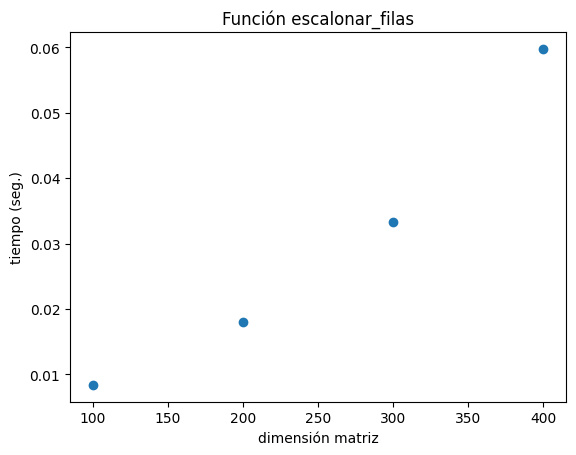

In [17]:
import matplotlib.pyplot as plt
x = np.array([100, 200, 300, 400])
t = np.array([t1, t2, t3, t4])
plt.title("Función escalonar_filas")
plt.xlabel("dimensión matriz")
plt.ylabel("tiempo (seg.)")
plt.scatter(x,t)